# 06 — Visualizaciones finales

## Modelo predictivo para anticipar incumplimientos de SLA en HR Operations  
## (Predictive Model to Anticipate SLA Breaches in HR Operations)

El objetivo de este notebook es generar los gráficos finales del proyecto.

Estas visualizaciones se utilizarán en:

- README.
- Presentación final.
- Informe del proyecto.
- Posible app de Streamlit.

Los gráficos se guardarán en la carpeta `reports/figures/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
os.makedirs("../reports/figures", exist_ok=True)

In [3]:
# Cargar dataset final:
ruta_datos = "../data/processed/tickets_hr_sla_model_ready.csv"

df = pd.read_csv(ruta_datos)

df.head()

,Customer Age,Product Purchased,Ticket Type,Ticket Subject,Ticket Priority,Ticket Channel,incumplio_sla
0,48,Dell XPS,Technical issue,Network problem,Low,Social media,0
1,27,Microsoft Office,Billing inquiry,Account access,Low,Social media,0
2,67,Autodesk AutoCAD,Billing inquiry,Data loss,Low,Email,0
3,48,Nintendo Switch,Cancellation request,Data loss,High,Phone,0
4,51,Microsoft Xbox Controller,Product inquiry,Software bug,High,Chat,1


In [4]:
# Cargar modelo final:
ruta_modelo = "../models/modelo_random_forest_sla.pkl"

modelo_final = joblib.load(ruta_modelo)

modelo_final

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Customer Age']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product Purchased',
                                                   'Ticket Type',
                                                   'Ticket Subject',
                                                   'Ticket Priority',
                                                   'Ticket Channel'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [5]:
# preparar X e y:
X = df.drop(columns="incumplio_sla")
y = df["incumplio_sla"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

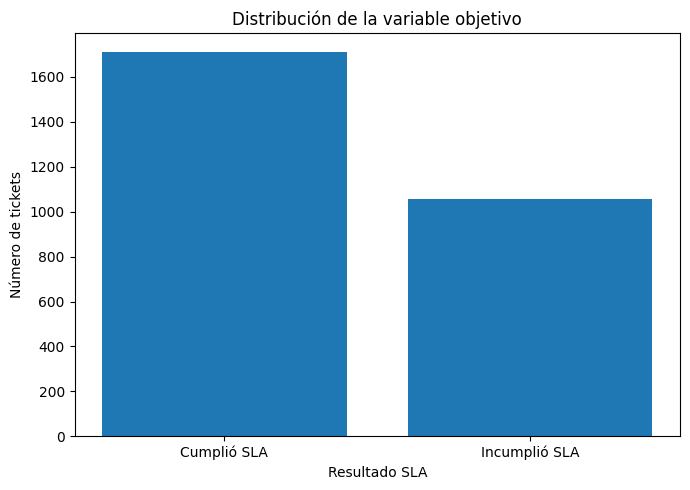

In [6]:
# Gráfico 1: distribución del target:
target_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Cumplió SLA", "Incumplió SLA"],
    target_counts.values
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado SLA")
plt.ylabel("Número de tickets")
plt.tight_layout()

plt.savefig("../reports/figures/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

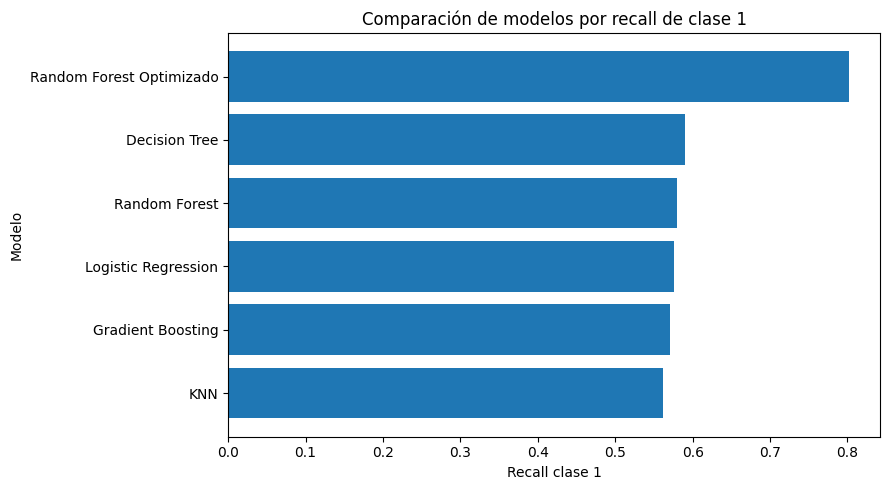

In [8]:
# Gráfico 2: comparación de modelos por recall:
resultados_modelos = pd.DataFrame({
    "modelo": [
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest Optimizado"
    ],
    "recall_clase_1": [
        0.5613,
        0.5755,
        0.5896,
        0.5802,
        0.5708,
        0.8019
    ]
})

resultados_recall = resultados_modelos.sort_values(
    by="recall_clase_1",
    ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    resultados_recall["modelo"],
    resultados_recall["recall_clase_1"]
)

plt.title("Comparación de modelos por recall de clase 1")
plt.xlabel("Recall clase 1")
plt.ylabel("Modelo")
plt.tight_layout()

plt.savefig("../reports/figures/model_comparison_recall.png", dpi=300, bbox_inches="tight")
plt.show()

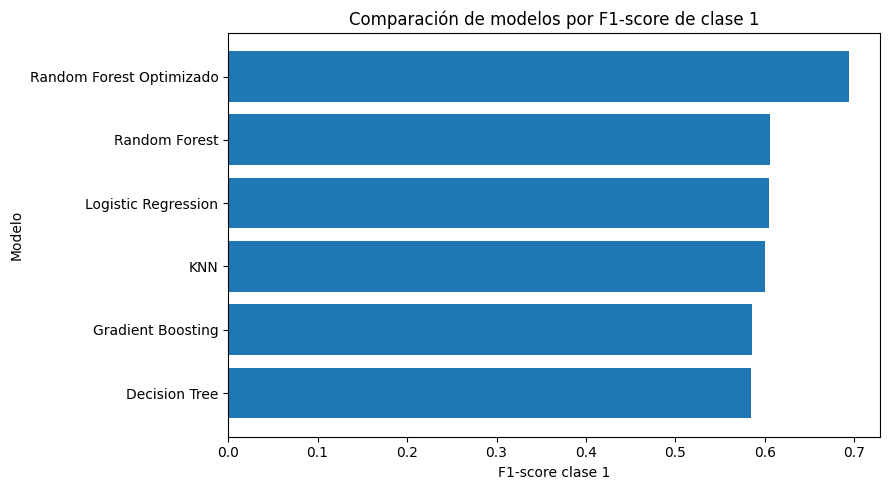

In [9]:
# Gráfico 3: comparación de modelos por F1-score:
resultados_modelos_f1 = pd.DataFrame({
    "modelo": [
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest Optimizado"
    ],
    "f1_clase_1": [
        0.5995,
        0.6040,
        0.5841,
        0.6059,
        0.5860,
        0.6939
    ]
})

resultados_f1 = resultados_modelos_f1.sort_values(
    by="f1_clase_1",
    ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    resultados_f1["modelo"],
    resultados_f1["f1_clase_1"]
)

plt.title("Comparación de modelos por F1-score de clase 1")
plt.xlabel("F1-score clase 1")
plt.ylabel("Modelo")
plt.tight_layout()

plt.savefig("../reports/figures/model_comparison_f1.png", dpi=300, bbox_inches="tight")
plt.show()

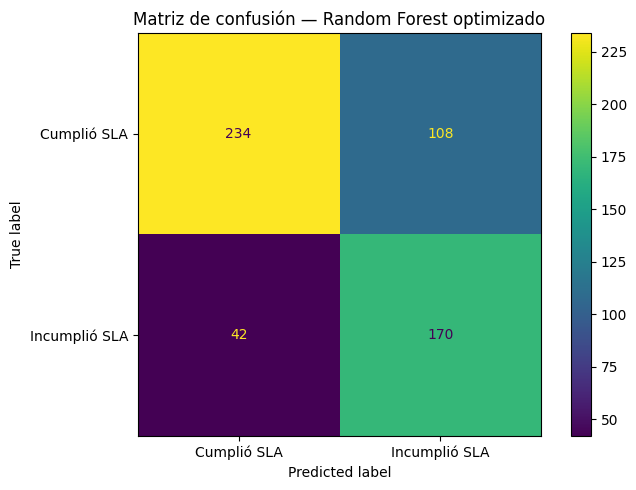

In [10]:
# Gráfico 4: matriz de confusión final:
y_pred_final = modelo_final.predict(X_test)

matriz_final = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=["Cumplió SLA", "Incumplió SLA"]
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, values_format="d")

plt.title("Matriz de confusión — Random Forest optimizado")
plt.tight_layout()

plt.savefig("../reports/figures/final_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Gráfico 5: importancia agregada por grupo de variables:
# Se reconstruirá la importancia de variables desde el modelo guardado.
preprocesador_entrenado = modelo_final.named_steps["preprocesamiento"]
modelo_entrenado = modelo_final.named_steps["modelo"]

columnas_numericas = ["Customer Age"]

columnas_categoricas = [
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Channel"
]

nombres_numericas = columnas_numericas

nombres_categoricas = (
    preprocesador_entrenado
    .named_transformers_["categoricas"]
    .get_feature_names_out(columnas_categoricas)
)

nombres_variables = list(nombres_numericas) + list(nombres_categoricas)

df_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": modelo_entrenado.feature_importances_
})

In [12]:
# Agrupar importancia:
def agrupar_variable(variable):
    if variable == "Customer Age":
        return "Customer Age"
    if variable.startswith("Product Purchased"):
        return "Product Purchased"
    if variable.startswith("Ticket Type"):
        return "Ticket Type"
    if variable.startswith("Ticket Subject"):
        return "Ticket Subject"
    if variable.startswith("Ticket Priority"):
        return "Ticket Priority"
    if variable.startswith("Ticket Channel"):
        return "Ticket Channel"
    return "Other"

df_importancias["grupo_variable"] = df_importancias["variable"].apply(agrupar_variable)

importancia_por_grupo = (
    df_importancias
    .groupby("grupo_variable", as_index=False)["importancia"]
    .sum()
    .sort_values(by="importancia", ascending=True)
)

importancia_por_grupo

,grupo_variable,importancia
2,Ticket Channel,0.021917
5,Ticket Type,0.023731
0,Customer Age,0.028330
4,Ticket Subject,0.049076
1,Product Purchased,0.103511
3,Ticket Priority,0.773435


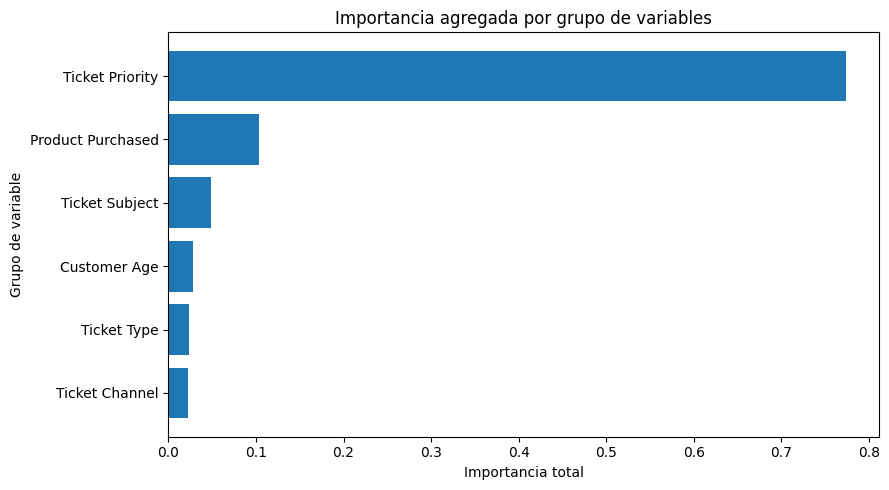

In [13]:
# Gráfico de importancia agregada:
plt.figure(figsize=(9, 5))
plt.barh(
    importancia_por_grupo["grupo_variable"],
    importancia_por_grupo["importancia"]
)

plt.title("Importancia agregada por grupo de variables")
plt.xlabel("Importancia total")
plt.ylabel("Grupo de variable")
plt.tight_layout()

plt.savefig("../reports/figures/feature_importance_groups.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
    # Verificar archivos guardados:
    os.listdir("../reports/figures")

['model_comparison_recall.png',
 'target_distribution.png',
 'model_comparison_f1.png',
 'feature_importance_groups.png',
 'final_confusion_matrix.png']

## Conclusión del notebook

En este notebook se generaron los gráficos finales del proyecto.

Las visualizaciones creadas resumen:

- Distribución de la variable objetivo.
- Comparación de modelos.
- Mejora del modelo optimizado.
- Matriz de confusión final.
- Importancia agregada de variables.

Estos gráficos serán utilizados en la presentación final y en la documentación ejecutiva del proyecto.